<a href="https://colab.research.google.com/github/SathyaPrakashD/PyTorch-for-Deep-Learning/blob/main/00_pytorch_fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 00. PyTorch Fundamentals

This notebook covers the fundamentals of **PyTorch tensors** — the core data structure used in deep learning.

**Topics covered:**
- Scalars, Vectors, Matrices (2D Tensors)
- 3D and 4D Tensors
- Random, Zero, and One Tensors
- Tensor shapes, dimensions, and how to read them
- Tensor datatypes and common errors
- Tensor operations (arithmetic and matrix multiplication)
- Tensor aggregation (min, max, mean, sum)
- Reshaping, stacking, squeezing, unsqueezing, and permuting
- Indexing (selecting data from tensors)
- Interoperability with NumPy
- Reproducibility with random seeds
- Running tensors on GPU

> **Mental model:** Read a tensor shape tuple left-to-right = outside-to-inside. The first number tells you *how many*, and the remaining numbers describe the shape of each one.

## Imports

Standard imports for a PyTorch workflow.

| Library | Purpose |
|---|---|
| `torch` | Core PyTorch library for tensors and neural networks |
| `numpy` | Numerical computing; used for NumPy ↔ Tensor conversions |
| `pandas` | Data manipulation and analysis |
| `matplotlib` | Plotting and data visualization |
| `seaborn` | Statistical data visualization (built on Matplotlib) |

> **Note:** We print the PyTorch version to confirm the environment is set up correctly.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')  # Suppress non-critical warnings for cleaner output

import torch
print(torch.__version__)  # Verify PyTorch version

2.10.0+cpu


## 1. Scalars

A **scalar** is a single number — a 0-dimensional tensor. It has no shape (empty `torch.Size([])`) and no axes.

| Property | Value |
|---|---|
| Shape | `torch.Size([])` |
| `ndim` | 0 |
| Example | `torch.tensor(7)` |

**Visualisation:** Just a single number. No axes, no directions. Think of it as a point on a number line.

> **Tip:** Use `.item()` to extract the raw Python number from a scalar tensor.

In [ ]:
# Create a scalar (0-dimensional tensor) — a single number with no axes
scalar = torch.tensor(7)
scalar

tensor(7)

In [ ]:
# .item() extracts the Python number from a scalar tensor
# Useful when you need a plain int/float (e.g., logging a loss value)
scalar.item()

7

In [ ]:
# A scalar has 0 dimensions (ndim = 0) — no axes at all
scalar.ndim

0

In [ ]:
# A scalar has an empty shape — torch.Size([]) — because there are no dimensions
scalar.shape

torch.Size([])

## 2. Vectors

A **vector** is a 1D tensor — an ordered list of numbers.

| Property | Value |
|---|---|
| Shape | `torch.Size([n])` |
| `ndim` | 1 |
| Example | `torch.tensor([7, 7])` |

**Visualisation:** A single row of numbers. Think of it as one row in a spreadsheet.

> **Convention (lowercase):** Vectors are typically denoted with a lowercase letter, e.g. `y = [1, 2, 3]`.

In [ ]:
# Create a vector (1-dimensional tensor) — an ordered list of numbers
vector = torch.tensor([7, 7])
vector

tensor([7, 7])

In [ ]:
# Shape: torch.Size([2]) → 2 elements, 1 dimension
vector.shape

torch.Size([2])

In [ ]:
# A vector has 1 dimension (ndim = 1)
vector.ndim

1

## 3. Matrices (2D Tensors)

A **matrix** is a 2D tensor — a table of numbers arranged in rows and columns.

| Property | Value |
|---|---|
| Shape | `torch.Size([rows, cols])` |
| `ndim` | 2 |
| Example | `torch.tensor([[7, 8], [9, 10]])` |

**Visualisation:** One spreadsheet with Rows × Columns.

> **Convention (uppercase):** Matrices are typically denoted with an uppercase letter, e.g. `X` or `W`.

In [ ]:
# Create a matrix (2-dimensional tensor) — a table of numbers with rows and columns
matrix = torch.tensor([[7, 8],
                        [9, 10]])
matrix

tensor([[ 7,  8],
        [ 9, 10]])

In [ ]:
# A matrix has 2 dimensions (ndim = 2) — rows and columns
matrix.ndim

2

In [ ]:
# Shape: torch.Size([2, 2]) → 2 rows, 2 columns
matrix.shape

torch.Size([2, 2])

## 4. 3D Tensors

A **3D tensor** adds another dimension — think of it as a stack (or batch) of matrices.

| Property | Value |
|---|---|
| Shape | `torch.Size([depth, rows, cols])` |
| `ndim` | 3 |
| Example | `torch.tensor([[[1,2,3],[3,6,9],[2,4,5]]])` |

**Visualisation:** A pile of spreadsheets.

```
(A, B, C)
 ↓   ↓   ↓
 A   B   C
 │   │   └── columns per sheet
 │   └─────── rows per sheet  
 └─────────── number of sheets
```

**Real-world example (NLP):** Shape `(64, 50, 300)` = 64 reviews × 50 tokens × 300 embedding dimensions.

> **Note:** 4D tensors (covered in the next cell) extend this concept further, commonly used for batches of images: `(batch, channels, height, width)`.

In [ ]:
# Create a 3D tensor — a stack of matrices
# Shape: (1, 3, 3) → 1 "sheet", each sheet has 3 rows and 3 columns
matric3d = torch.tensor([[[1, 2, 3],
                           [3, 6, 9],
                           [2, 4, 5]]])
matric3d

tensor([[[1, 2, 3],
         [3, 6, 9],
         [2, 4, 5]]])

In [ ]:
# 3D tensor has 3 dimensions (ndim = 3)
matric3d.ndim

3

In [ ]:
# Shape: torch.Size([1, 3, 3]) → 1 matrix, 3 rows, 3 columns
matric3d.shape

torch.Size([1, 3, 3])

In [ ]:
# Create a 4D tensor — a batch of stacked matrices
# Common use: image batches → (batch_size, channels, height, width)
# Shape: (1, 1, 3, 3) → 1 batch, 1 channel, 3 rows, 3 columns
matrix4d = torch.tensor([[[[1, 2, 3],
                            [3, 6, 9],
                            [2, 4, 5]]]])
matrix4d

tensor([[[[1, 2, 3],
          [3, 6, 9],
          [2, 4, 5]]]])

In [ ]:
# 4D tensor has 4 dimensions (ndim = 4)
matrix4d.ndim

4

In [ ]:
# Shape: torch.Size([1, 1, 3, 3]) → (batch, channels, height, width)
matrix4d.shape

torch.Size([1, 1, 3, 3])

## Random Tensors

### Why Random Tensors?

Random tensors are fundamental to how neural networks learn. The typical training loop is:

```
Start with random numbers
    → Look at data
    → Update random numbers to better represent the data
    → Repeat
```

Neural networks are initialized with random weights, and the learning process (via backpropagation and gradient descent) gradually adjusts these values to minimize the loss.

> **Key function:** `torch.rand(size)` generates a tensor of uniform random values in the range `[0, 1)`.

In [ ]:
# Create a random tensor of shape (3, 4) — values drawn from uniform distribution [0, 1)
random_tensor = torch.rand(3, 4)
random_tensor

tensor([[0.2787, 0.6873, 0.3540, 0.1362],
        [0.4787, 0.2846, 0.2702, 0.1725],
        [0.9332, 0.3723, 0.5170, 0.8631]])

In [ ]:
# Confirm shape: 3 rows, 4 columns
random_tensor.shape

torch.Size([3, 4])

In [ ]:
# A 2D tensor (matrix) has ndim = 2
random_tensor.ndim

2

In [ ]:
# Create a random tensor mimicking an RGB image
# Shape: (height, width, colour_channels) — the standard HWC format used by PIL/OpenCV
# Note: PyTorch CNNs expect CHW format (channels, height, width) — use permute() to convert
random_image_size_tensor = torch.rand(size=(224, 224, 3))  # height=224, width=224, RGB channels=3
random_image_size_tensor.shape, random_image_size_tensor.ndim, random_image_size_tensor.shape

(torch.Size([224, 224, 3]), 3, torch.Size([224, 224, 3]))

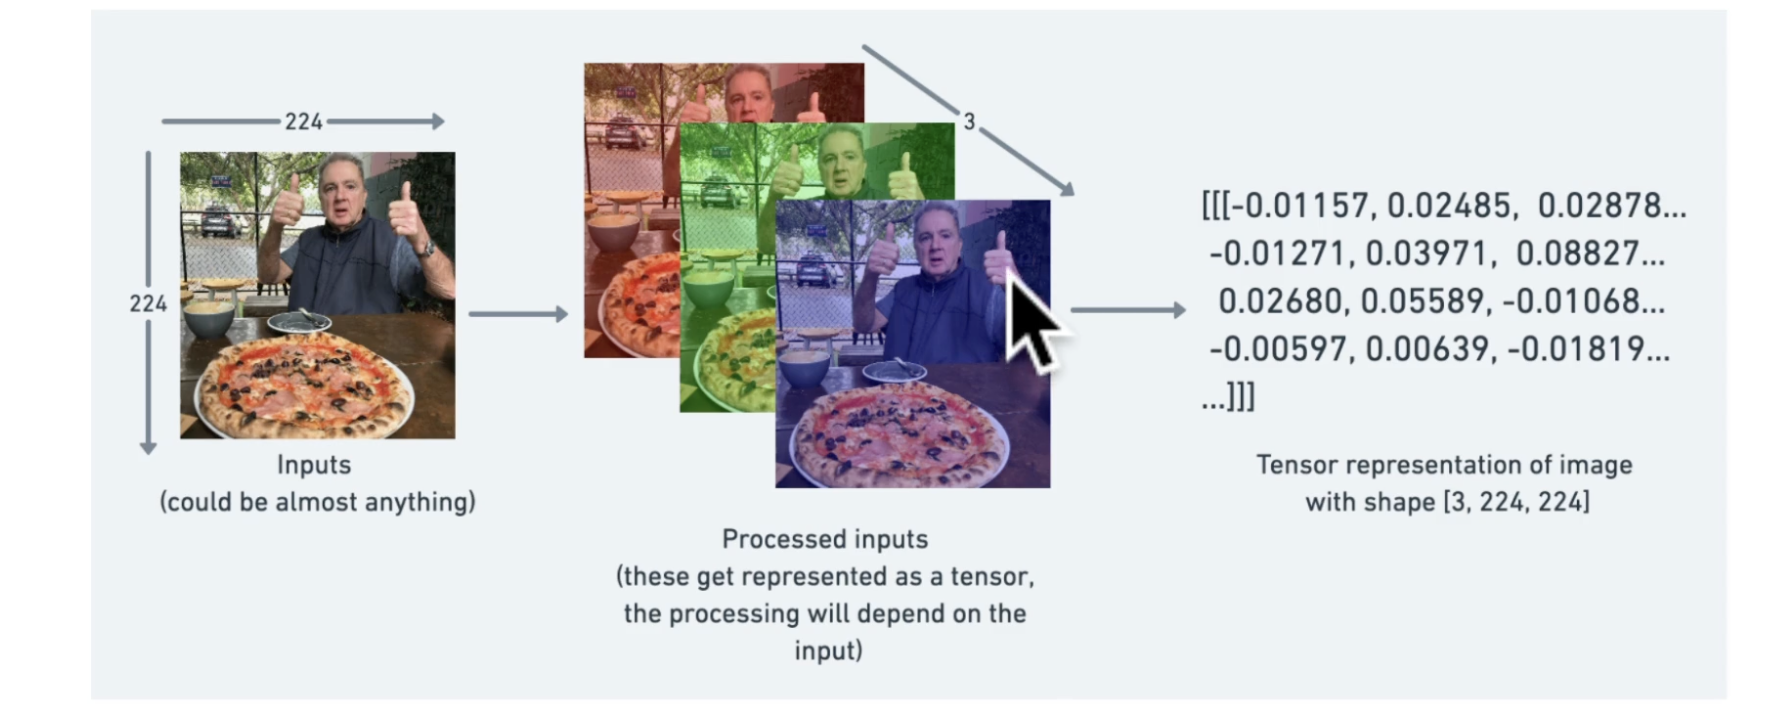

## Zeros and Ones

`torch.zeros()` and `torch.ones()` create tensors filled with 0s or 1s respectively.

**Common uses:**
- `torch.zeros()`: Creating zero-initialized weight tensors or masks
- `torch.ones()`: Creating bias tensors initialized to 1 or identity-like masks

> **Note:** By default, both functions create tensors with `dtype=torch.float32`.

In [ ]:
# Create tensors filled with zeros and ones of shape (2, 3)
# torch.zeros → often used for initializing masks or zero-filled weight matrices
# torch.ones  → often used for bias initialization or creating all-true masks
zeros = torch.zeros(2, 3)
ones = torch.ones(2, 3)
zeros, ones

(tensor([[0., 0., 0.],
         [0., 0., 0.]]),
 tensor([[1., 1., 1.],
         [1., 1., 1.]]))

In [ ]:
# Both torch.zeros() and torch.ones() default to dtype=torch.float32
ones.dtype, zeros.dtype

(torch.float32, torch.float32)

## Creating a Range of Tensors and Tensors-Like

- **`torch.range(start, end)`** — Creates a 1D tensor from `start` to `end` (inclusive). ⚠️ Deprecated; prefer `torch.arange()`.
- **`torch.arange(start, end, step)`** — Creates a 1D tensor like Python's `range()` (end is *exclusive*).
- **`torch.zeros_like(tensor)`** — Creates a zero tensor with the same shape and dtype as the input tensor.
- **`torch.ones_like(tensor)`** — Creates a ones tensor with the same shape and dtype as the input tensor.

> **Best practice:** Use `torch.arange()` instead of the deprecated `torch.range()` to avoid `UserWarning`.

In [ ]:
# Create a 1D tensor from 0 to 10 (inclusive) using torch.range()
# ⚠️  torch.range() is deprecated — use torch.arange() instead
# torch.arange(0, 11) is equivalent and avoids the UserWarning
one_to_ten = torch.range(0, 10)
one_to_ten

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

In [ ]:
# Create a zero tensor with the same shape and dtype as one_to_ten
# torch.zeros_like() is useful when you want a blank canvas matching an existing tensor
ten_zeros = torch.zeros_like(input=one_to_ten)
ten_zeros

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

## Tensor Datatypes

**Note:** Tensor datatypes is one of the 3 big sources of errors in PyTorch & deep learning:

1. **Tensors not right datatype** — e.g., passing `int64` where `float32` is expected
2. **Tensors not right shape** — mismatched dimensions during operations
3. **Tensors not on right device** — mixing CPU and GPU tensors

### Common PyTorch Datatypes

| Dtype | Description | Usage |
|---|---|---|
| `torch.float32` | 32-bit floating point (default) | General deep learning |
| `torch.float16` | 16-bit floating point | Mixed-precision / GPU speedup |
| `torch.int32` | 32-bit integer | Index tensors |
| `torch.int64` / `torch.long` | 64-bit integer (default for int tensors) | Labels, indices |
| `torch.bool` | Boolean | Masks |

### Precision Trade-off

Higher precision (e.g., `float64`) uses more memory but is more numerically accurate. In deep learning, `float32` is the standard balance between speed and precision. `float16` (half precision) is used to speed up training on modern GPUs via **mixed precision training**.

> **Key functions:** `tensor.type(new_dtype)` or `tensor.to(dtype=new_dtype)` to cast between types.

In [ ]:
# Create a float32 tensor (default dtype in PyTorch)
# dtype=None  → defaults to torch.float32 for floats
# device=None → defaults to CPU
# requires_grad=False → do not track gradients (set True for learnable parameters)
float_32_tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype=None,          # Data type of tensor (defaults to float32)
                               device=None,          # Device: 'cpu' or 'cuda' (defaults to cpu)
                               requires_grad=False)  # Track gradients for autograd (False = inference only)
float_32_tensor

tensor([3., 6., 9.])

In [ ]:
# Confirm the default dtype is torch.float32
float_32_tensor.dtype

torch.float32

In [ ]:
# Cast float32 tensor to float16 (half precision)
# float16 uses half the memory and is faster on modern GPUs (used in mixed-precision training)
float_16_tensor = float_32_tensor.type(torch.float16)
float_16_tensor

tensor([3., 6., 9.], dtype=torch.float16)

In [ ]:
# PyTorch automatically handles mixed-precision arithmetic
# float16 * float32 → result is float32 (upcasted to the higher precision)
float_16_tensor * float_32_tensor

tensor([ 9., 36., 81.])

In [ ]:
# Create an integer (int32) tensor
# Note: integer tensors cannot be used with some ops like torch.mean() directly
int_32_tensor = torch.tensor([3, 6, 6], dtype=torch.int32)
int_32_tensor

tensor([3, 6, 6], dtype=torch.int32)

In [ ]:
# Perform element-wise multiplication: int32 * float16
# PyTorch upcasts int32 to float16 for the operation → result is float16
int_32_tensor * float_16_tensor

tensor([ 9., 36., 54.], dtype=torch.float16)

In [ ]:
# Create a long (int64) tensor
# torch.long is the default integer dtype — commonly used for class labels/indices
long_tensor = torch.tensor([3, 6, 6], dtype=torch.long)
long_tensor

tensor([3, 6, 6])

In [ ]:
# Perform element-wise multiplication: long (int64) * float16
# PyTorch upcasts int64 to float16 → result is float16
long_tensor * float_16_tensor

tensor([ 9., 36., 54.], dtype=torch.float16)

## Getting Information from Tensors — Tensor Attributes

Every PyTorch tensor has three key attributes:

| Attribute | Method | Description |
|---|---|---|
| Data type | `tensor.dtype` | The element type (e.g., `torch.float32`) |
| Shape | `tensor.shape` or `tensor.size()` | The size along each dimension |
| Device | `tensor.device` | Where the tensor lives (`cpu` or `cuda:0`) |

> **Debugging tip:** When you get an error, the first thing to check is: what are the dtype, shape, and device of the tensors involved?

In [ ]:
# Create a random (3, 4) tensor to demonstrate attribute inspection
some_tensor = torch.rand(3, 4)
some_tensor

tensor([[0.8502, 0.8704, 0.1223, 0.9882],
        [0.5754, 0.5674, 0.6650, 0.5640],
        [0.6967, 0.5926, 0.7565, 0.8136]])

In [ ]:
# Check the data type — torch.float32 is the default for torch.rand()
some_tensor.dtype

torch.float32

In [ ]:
# Check the shape — (3, 4) means 3 rows, 4 columns
some_tensor.shape

torch.Size([3, 4])

In [ ]:
# Check which device the tensor is on — 'cpu' by default
some_tensor.device

device(type='cpu')

In [ ]:
# tensor.size() and tensor.shape return the same information
# size() is a method; shape is a property — both return torch.Size
some_tensor.size()

torch.Size([3, 4])

## Manipulating Tensors (Tensor Operations)

Tensor operations are the building blocks of neural networks. PyTorch supports:

| Operation | Python Operator | PyTorch Function |
|---|---|---|
| Addition | `tensor + n` | `torch.add(tensor, n)` |
| Subtraction | `tensor - n` | `torch.sub(tensor, n)` |
| Multiplication | `tensor * n` | `torch.mul(tensor, n)` |
| Division | `tensor / n` | `torch.div(tensor, n)` |
| Matrix Multiplication | `tensor @ tensor` | `torch.matmul(a, b)` |

> **Key insight:** Neural networks learn by repeatedly applying these operations to tensors (weights × inputs + biases) and adjusting the weights to minimise a loss function.

In [ ]:
# Create a 1D tensor with values [1, 2, 3] to demonstrate basic operations
tensor = torch.tensor([1, 2, 3])

In [ ]:
# Scalar addition: adds 10 to every element (broadcasting)
tensor + 10

tensor([11, 12, 13])

In [ ]:
# Scalar multiplication: multiplies every element by 10 (broadcasting)
tensor * 10

tensor([10, 20, 30])

In [ ]:
# Scalar subtraction: subtracts 10 from every element (broadcasting)
tensor - 10

tensor([-9, -8, -7])

In [ ]:
# PyTorch built-in multiplication function — equivalent to tensor * 10
# Prefer operators (+, -, *, /) for readability, but torch functions can be useful in functional APIs
torch.mul(tensor, 10)

tensor([10, 20, 30])

In [ ]:
# PyTorch built-in addition function — equivalent to tensor + 10
torch.add(tensor, 10)

tensor([11, 12, 13])

## Matrix Multiplication

Matrix multiplication (also called the **dot product**) is the most important operation in deep learning — it's at the heart of every linear layer in a neural network.

### Two Ways to Multiply Tensors

| Method | Description | Example |
|---|---|---|
| **Element-wise** | Multiply corresponding elements | `tensor * tensor` |
| **Matrix multiplication** | Dot product of rows and columns | `tensor @ tensor` or `torch.matmul(a, b)` |

### Rules for Matrix Multiplication

**Rule 1 — Inner dimensions must match:**

```
(3, 2) @ (3, 2)  ✗  — inner dims: 2 ≠ 3
(2, 3) @ (3, 2)  ✓  — inner dims: 3 = 3
(3, 2) @ (2, 3)  ✓  — inner dims: 2 = 2
```

**Rule 2 — The result shape is the outer dimensions:**

```
(3, 2) @ (2, 3)  → result shape: (3, 3)
(2, 3) @ (3, 2)  → result shape: (2, 2)
```

> **Fix for shape mismatch:** Transpose one of the tensors using `.T` or `torch.transpose()` to align the inner dimensions.

### Scalar Multiplication and Element-Wise Multiplication

**Scalar multiplication** multiplies every element in a tensor by a single number.

**Element-wise multiplication** (also called the *Hadamard product*) multiplies two tensors of the **same shape** position by position.

> Both operations do NOT require matching inner dimensions — they only require matching shapes (or broadcastable shapes).

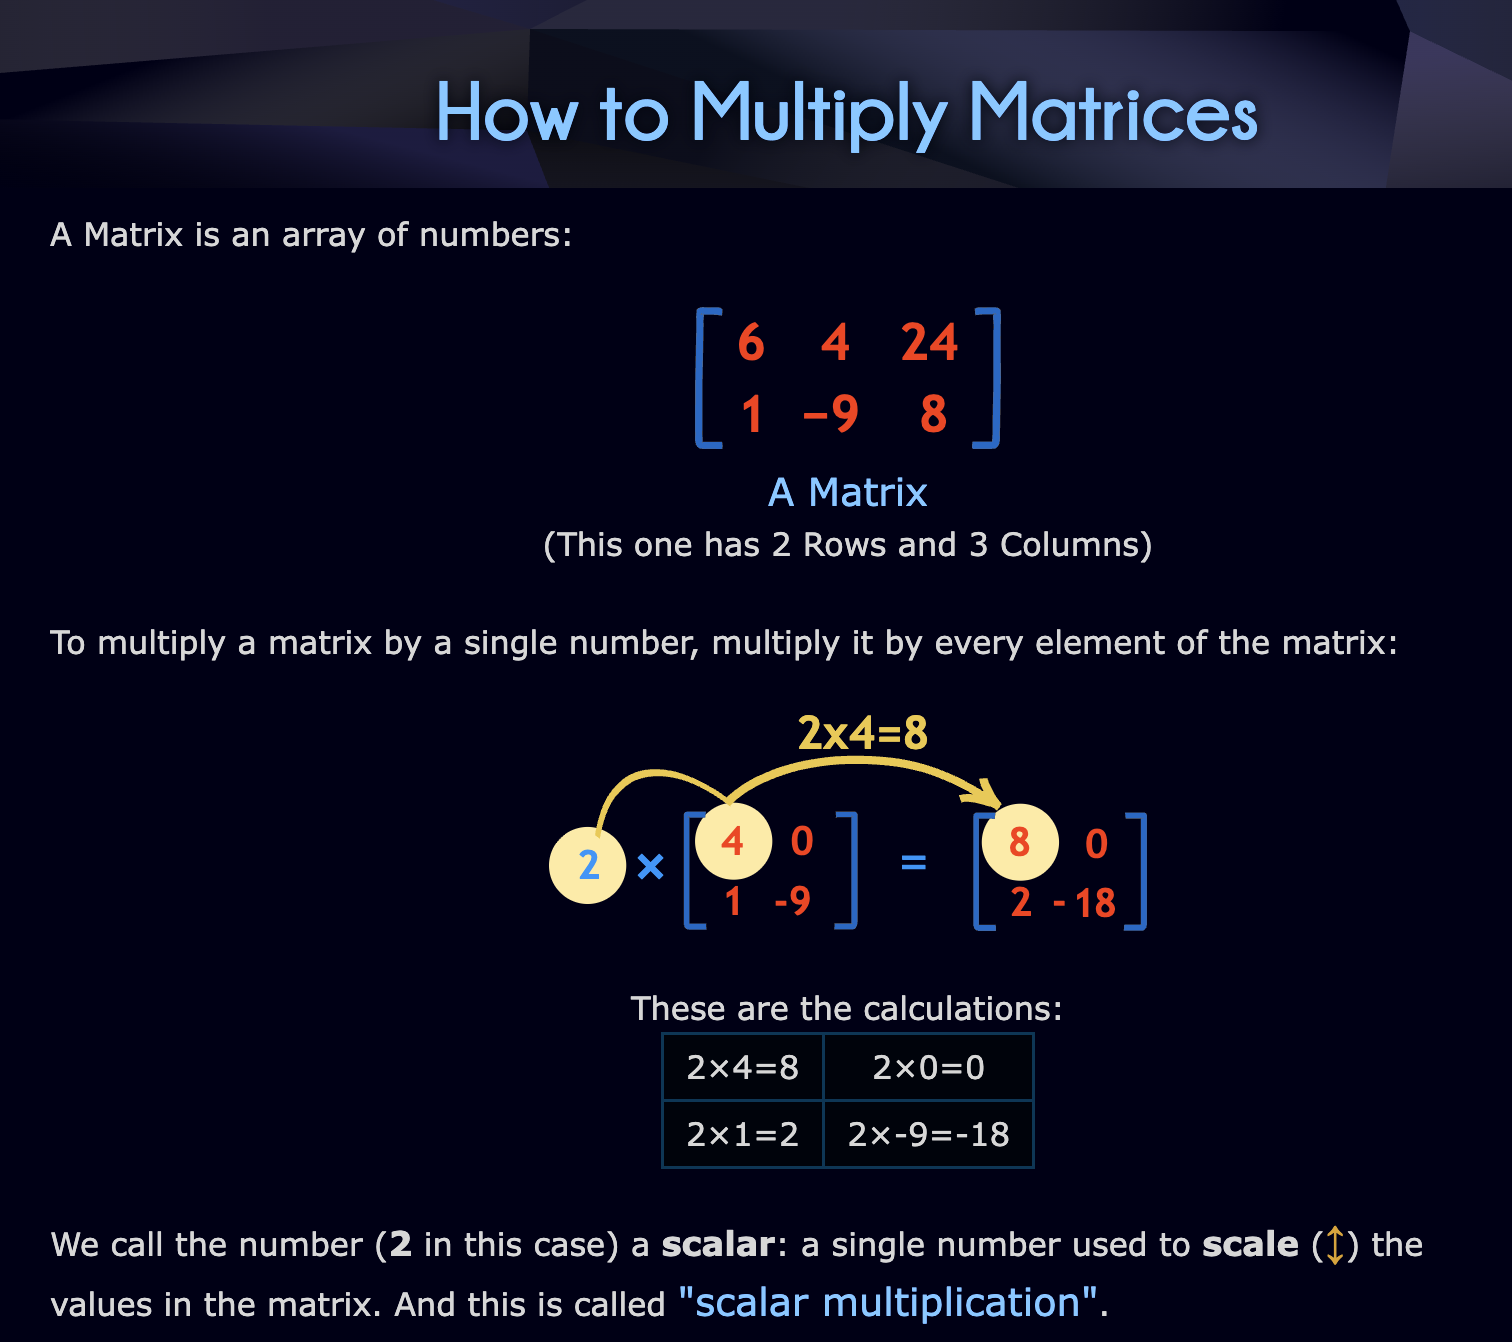

### Multiplying a Matrix by Another Matrix

Matrix multiplication (dot product) follows strict dimension rules:
- The **inner dimensions must match**: `(m, n) @ (n, p)` is valid.
- The **output shape** is `(m, p)` — the outer dimensions.

This operation is at the core of linear layers: **output = input @ weights.T + bias**.

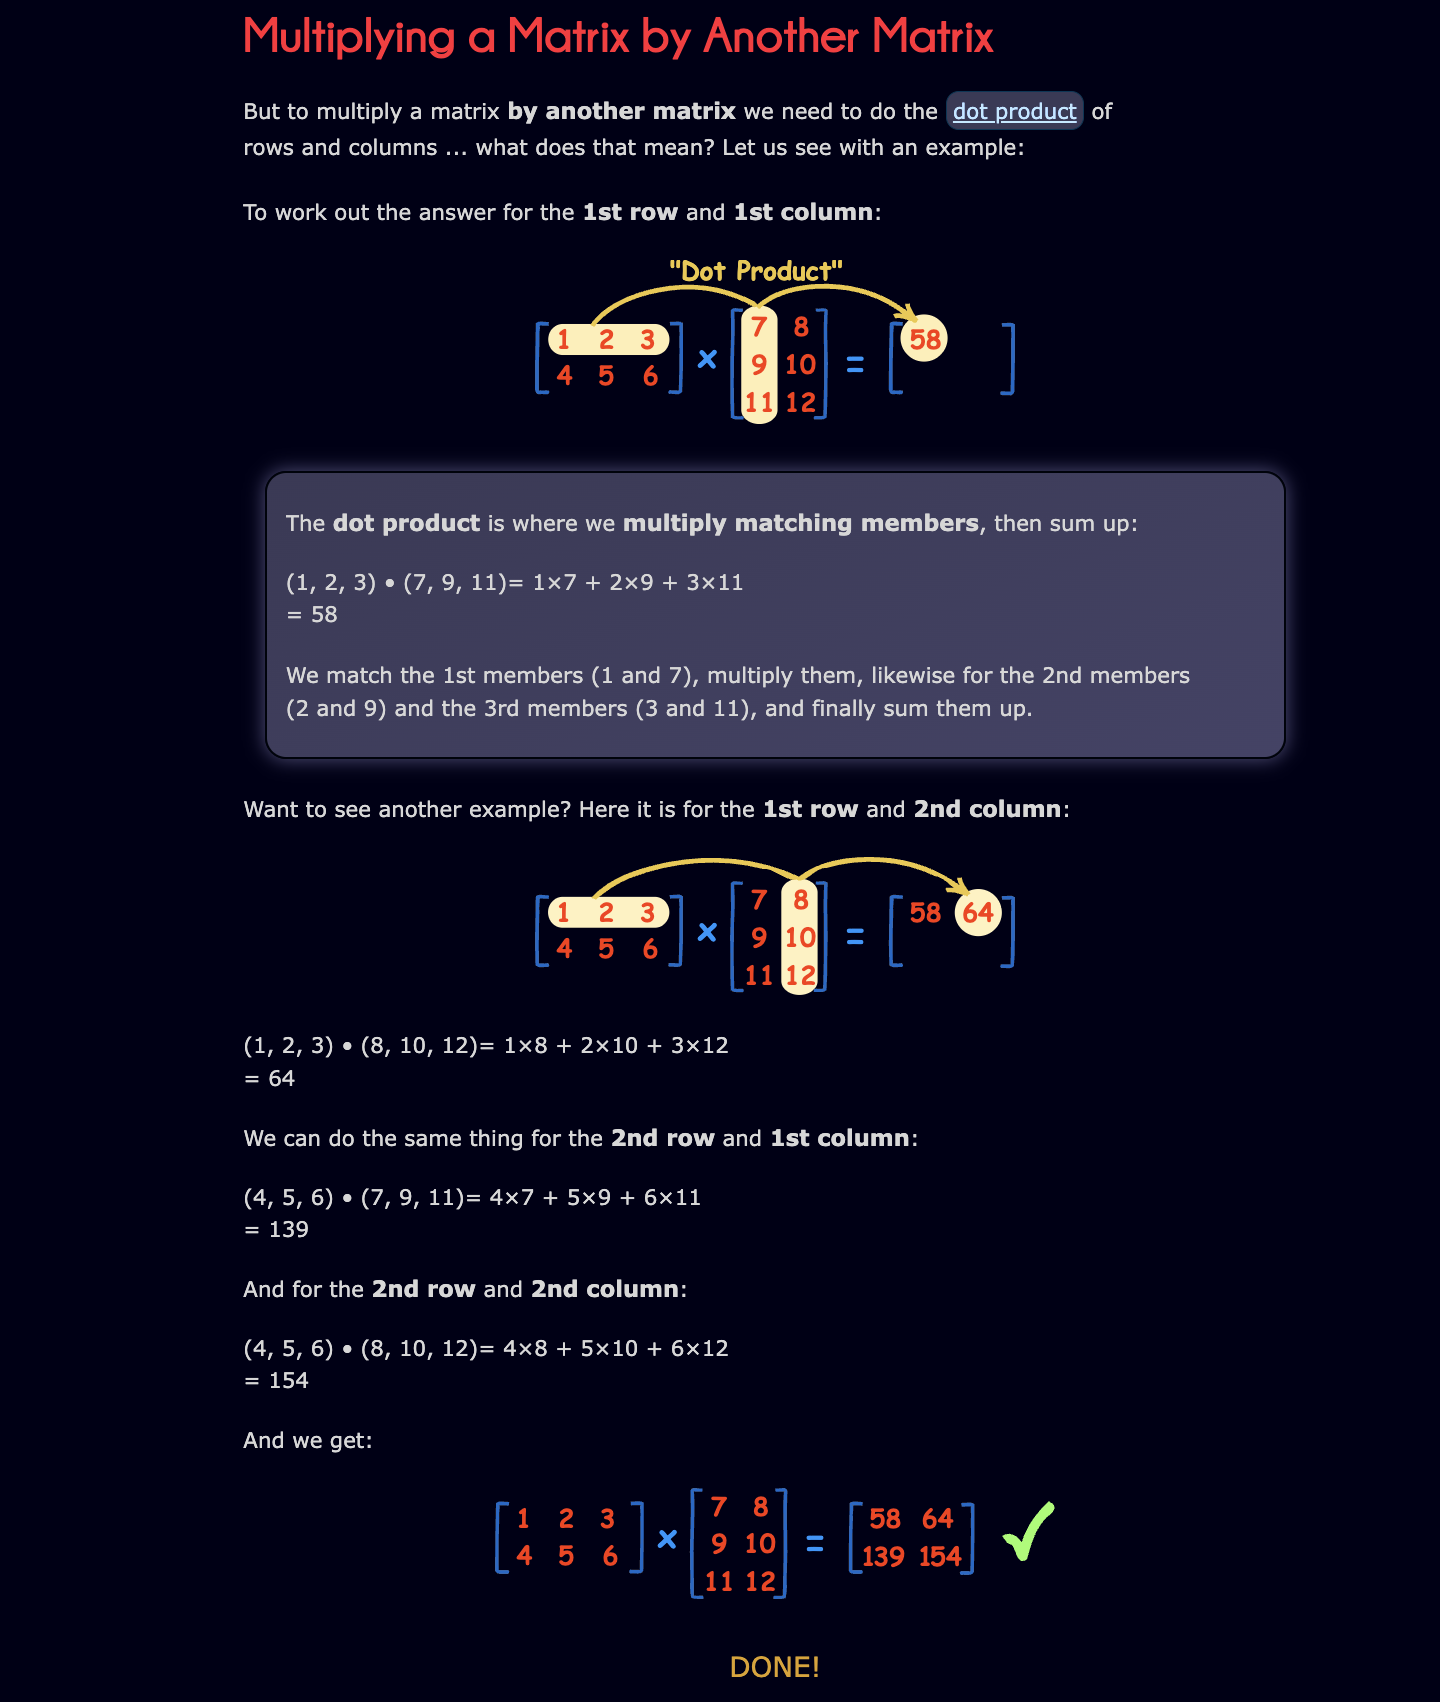

In [ ]:
# Element-wise multiplication (Hadamard product): each element is multiplied by itself
# Result: [1*1, 2*2, 3*3] = [1, 4, 9]
# This is NOT matrix multiplication — no inner dimension rule applies here
print(tensor, "*", tensor)
print(f"Equals - {tensor * tensor}")

tensor([1, 2, 3]) * tensor([1, 2, 3])
 Equals - tensor([1, 4, 9])


In [ ]:
# Matrix multiplication (dot product) using .matmul()
# For 1D tensors, this computes the inner product: 1*1 + 2*2 + 3*3 = 14
# %%time measures execution time — matrix multiplication is very fast on modern hardware
%%time
tensor.matmul(tensor)

CPU times: user 1.11 ms, sys: 10 µs, total: 1.12 ms
Wall time: 964 µs


tensor(14)

In [ ]:
# Manual computation of the same dot product: 1*1 + 2*2 + 3*3 = 14
# Comparing with %%time above shows how much faster PyTorch's C++ backend is vs pure Python
%%time
1*1 + 2*2 + 3*3

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 6.91 µs


14

### ⚠️ Shape Errors — One of the Most Common Errors in Deep Learning

A **shape error** occurs when you try to perform an operation on tensors whose dimensions are incompatible.

For matrix multiplication `(A @ B)`:
- `tensor_A` has shape `(3, 2)` → 3 rows, 2 columns
- `tensor_B` has shape `(3, 2)` → 3 rows, 2 columns
- Inner dimensions: `2 ≠ 3` → **RuntimeError!**

**Fix:** Transpose one of the tensors so the inner dimensions match. For example, `tensor_A @ tensor_B.T` gives `(3, 2) @ (2, 3) = (3, 3)`.

In [ ]:
# Create two (3, 2) tensors to demonstrate matrix multiplication shape rules
# Both have shape (3, 2): 3 rows, 2 columns
tensor_A = torch.tensor([[1,  2],
                          [3,  4],
                          [5,  6]])

tensor_B = torch.tensor([[7,  8],
                          [9,  10],
                          [11, 12]])

In [ ]:
# Both tensors are (3, 2) — this will cause a shape error for matmul
# Inner dimensions: 2 (from A) vs 3 (from B) → mismatch!
tensor_A.shape, tensor_B.shape

(torch.Size([3, 2]), torch.Size([3, 2]))

In [ ]:
# ⚠️ This will raise a RuntimeError!
# torch.matmul(tensor_A, tensor_B) requires: A.shape[-1] == B.shape[-2]
# Here: 2 != 3 → shapes (3,2) and (3,2) are incompatible for matmul
# Fix: transpose tensor_B → shape becomes (2,3), inner dim: 2 == 2 ✓
torch.matmul(tensor_A, tensor_B)

TypeError: matmul() takes 1 positional argument but 2 were given

> **Error explained:** The matrix multiplication `tensor_A @ tensor_B` failed because both tensors have shape `(3, 2)`. The inner dimensions are `2` and `3`, which do not match. To fix this, transpose `tensor_B` so its shape becomes `(2, 3)`, making the inner dimensions compatible (`2 = 2`).

Let's fix the shape error by transposing `tensor_B` using `.T`. This swaps the rows and columns, changing its shape from `(3, 2)` to `(2, 3)` so that the inner dimensions align for matrix multiplication.

In [ ]:
# Fix the shape error by transposing tensor_B
# tensor_B.T changes shape from (3, 2) → (2, 3)
# Now: (3, 2) @ (2, 3) → inner dims match (2 == 2) → result shape: (3, 3)
print(f"Original tensor_A shape:   {tensor_A.shape}")
print(f"Original tensor_B shape:   {tensor_B.shape}")
print(f"Transposed tensor_B shape: {tensor_B.T.shape}")

matrix_multiplied_tensor = tensor_A @ tensor_B.T  # @ is shorthand for torch.matmul()
print(f"\nResult of matrix multiplication (tensor_A @ tensor_B.T):\n{matrix_multiplied_tensor}")
print(f"Shape of result: {matrix_multiplied_tensor.shape}")

Original tensor_A shape: torch.Size([3, 2])
Original tensor_B shape: torch.Size([3, 2])
Transposed tensor_B shape: torch.Size([2, 3])
Result of matrix multiplication (tensor_A @ tensor_B.T):
tensor([[ 23,  29,  35],
        [ 53,  67,  81],
        [ 83, 105, 127]])
Shape of result: torch.Size([3, 3])


In [ ]:
# Element-wise multiplication of tensor_A and tensor_B (same shape: both 3x2)
# Multiplies corresponding elements: result shape is also (3, 2)
# This is different from matrix multiplication!
tensor_A * tensor_B

tensor([[ 7, 16],
        [27, 40],
        [55, 72]])

## Finding Min, Max, Mean, Sum, etc. — Tensor Aggregation

**Aggregation** reduces a tensor to a summary statistic. These functions are used throughout ML (e.g., computing average loss, finding the predicted class with the highest probability).

| Operation | Function | Method |
|---|---|---|
| Minimum | `torch.min(x)` | `x.min()` |
| Maximum | `torch.max(x)` | `x.max()` |
| Mean | `torch.mean(x)` | `x.mean()` |
| Sum | `torch.sum(x)` | `x.sum()` |
| Argmin | `torch.argmin(x)` | `x.argmin()` |
| Argmax | `torch.argmax(x)` | `x.argmax()` |

> **Important:** `torch.mean()` only works on floating-point tensors. If your tensor has `dtype=torch.int64`, you must cast it first with `.type(torch.float32)`.

In [ ]:
# Create a 1D tensor from 0 to 90 (step=10) for aggregation demonstrations
# torch.arange(start, end, step) — end is exclusive
x = torch.arange(0, 100, 10)
x

tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

In [ ]:
# Find the minimum value — both torch.min() and .min() are equivalent
torch.min(x), x.min()

(tensor(0), tensor(0))

In [ ]:
# Find the maximum value — both torch.max() and .max() are equivalent
torch.max(x), x.max()

(tensor(90), tensor(90))

In [ ]:
# Attempt to compute the mean — this will raise a RuntimeError!
# torch.mean() requires a floating-point tensor; x has dtype=torch.int64 (Long)
torch.mean(x)

RuntimeError: mean(): could not infer output dtype. Input dtype must be either a floating point or complex dtype. Got: Long

In [ ]:
# Confirm the dtype: torch.int64 (Long) — this is why torch.mean() failed above
x.dtype

torch.int64

> **Error explained:** `torch.mean()` raised a `RuntimeError` because the tensor `x` has `dtype=torch.int64` (Long). Mean requires a floating-point tensor.
> **Fix:** Cast the tensor to `float32` first: `torch.mean(x.type(torch.float32))` or `x.float().mean()`.

In [ ]:
# Fix: cast to float32 before computing mean
# x.type(torch.float32) creates a float copy of the tensor (original x is unchanged)
# Both approaches are equivalent: torch.mean(x.type(...)) and x.type(...).mean()
torch.mean(x.type(torch.float32)), x.type(torch.float32).mean()

(tensor(45.), tensor(45.))

In [ ]:
# Find the sum of all elements in the tensor
# torch.sum() works on integer tensors (unlike torch.mean())
torch.sum(x), x.sum()

(tensor(450), tensor(450))

## Finding the Position of Min and Max — `argmin` and `argmax`

`argmin()` and `argmax()` return the **index** (position) of the minimum and maximum values in a tensor — not the values themselves.

**Why this matters in ML:** After a model makes predictions, the final output is usually a vector of scores (logits). The predicted class is the index of the highest score — which is exactly what `argmax()` returns.

```python
predictions = model(input)      # e.g., tensor([0.1, 0.8, 0.05, 0.05])
predicted_class = predictions.argmax()  # → tensor(1) → class index 1
```

In [ ]:
# argmin() returns the INDEX of the minimum value (not the value itself)
# x[0] = 0 is the minimum → index 0
x, x.argmin(), x[x.argmin()]

(tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90]), tensor(0), tensor(0))

In [ ]:
# argmax() returns the INDEX of the maximum value
# x[9] = 90 is the maximum → index 9
# In classification tasks, argmax() on model outputs gives the predicted class
x, x.argmax(), x[x.argmax()]

(tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90]), tensor(9), tensor(90))

## Reshaping, Stacking, Squeezing and Unsqueezing Tensors

These operations change the *shape* of tensors without changing their underlying data (except stacking, which combines tensors).

| Operation | Function | Description |
|---|---|---|
| **Reshape** | `tensor.reshape(shape)` | Returns a tensor with a new shape. Total elements must match. |
| **View** | `tensor.view(shape)` | Like `reshape`, but always shares memory with the original. Modifying the view modifies the original. |
| **Stack** | `torch.stack([t1, t2, ...])` | Joins tensors along a *new* dimension. All tensors must have the same shape. |
| **Squeeze** | `tensor.squeeze()` | Removes all dimensions of size 1. |
| **Unsqueeze** | `tensor.unsqueeze(dim)` | Adds a new dimension of size 1 at the specified position. |
| **Permute** | `tensor.permute(dims)` | Rearranges dimensions in the specified order. Returns a view. |

> **reshape vs view:** `view()` requires the tensor to be contiguous in memory. If it isn't, use `reshape()` which handles this automatically (may return a copy).

In [ ]:
# Create a 1D tensor with 9 elements for reshaping demonstrations
import torch
x = torch.arange(1., 10.)
x, x.shape

(tensor([1., 2., 3., 4., 5., 6., 7., 8., 9.]), torch.Size([9]))

In [ ]:
# x is a 1D tensor (ndim = 1) with shape (9,)
x.ndim

1

In [ ]:
# Reshape x from (9,) to (1, 9) — total elements: 1×9 = 9 ✓
# Adding a new dimension is a common pattern before feeding into a model
x_reshaped = x.reshape(1, 9)
x_reshaped, x_reshaped.shape

(tensor([[1., 2., 3., 4., 5., 6., 7., 8., 9.]]), torch.Size([1, 9]))

In [ ]:
# ⚠️ This will raise a RuntimeError!
# Attempting to reshape (9,) to (2, 9) requires 2×9 = 18 elements, but x only has 9
# The total number of elements must be preserved when reshaping
x_reshaped = x.reshape(2, 9)
x_reshaped, x_reshaped.shape

RuntimeError: shape '[2, 9]' is invalid for input of size 9

> **Error explained:** `x.reshape(2, 9)` fails because `2 × 9 = 18`, but the tensor `x` only has **9 elements**. The total number of elements must be preserved. Valid reshapes for 9 elements include: `(1, 9)`, `(9, 1)`, `(3, 3)`.

In [ ]:
# Create a view of x with shape (1, 9)
# view() shares the same memory as x — modifying z also modifies x
z = x.view(1, 9)
z, z.shape

(tensor([[1., 2., 3., 4., 5., 6., 7., 8., 9.]]), torch.Size([1, 9]))

In [ ]:
# Access the first element of each row in z using slice notation
# z[:, 0] selects all rows (:), column 0 → returns the first element
z[:, 0]

tensor([1.])

In [ ]:
# Modify z in-place: set all values at column 0 to 5
# Because z and x share memory, this also changes x!
# This demonstrates that view() is a memory-sharing operation, not a copy
z[:, 0] = 5
z, x

(tensor([[5., 2., 3., 4., 5., 6., 7., 8., 9.]]),
 tensor([5., 2., 3., 4., 5., 6., 7., 8., 9.]))

In [ ]:
# Confirm x was also modified by changing z — they share memory
x, x.ndim, x.shape

(tensor([5., 2., 3., 4., 5., 6., 7., 8., 9.]), 1, torch.Size([9]))

In [ ]:
# Stack 4 copies of x along a new dimension (dim=0 by default)
# All tensors must have identical shapes before stacking
# Result shape: (4, 9) — 4 stacked rows of 9 elements each
x_stacked = torch.stack([x, x, x, x])
x_stacked, x_stacked.shape, x_stacked.ndim

(tensor([[5., 2., 3., 4., 5., 6., 7., 8., 9.],
         [5., 2., 3., 4., 5., 6., 7., 8., 9.],
         [5., 2., 3., 4., 5., 6., 7., 8., 9.],
         [5., 2., 3., 4., 5., 6., 7., 8., 9.]]),
 torch.Size([4, 9]),
 2)

In [ ]:
# Create a tensor with several size-1 dimensions to demonstrate squeeze()
# Shape (2, 1, 2, 1, 2) has two dimensions with size=1 (at positions 1 and 3)
x = torch.zeros(2, 1, 2, 1, 2)
x, x.shape, x.ndim

(tensor([[[[[0., 0.]],
 
           [[0., 0.]]]],
 
 
 
         [[[[0., 0.]],
 
           [[0., 0.]]]]]),
 torch.Size([2, 1, 2, 1, 2]),
 5)

In [ ]:
# torch.squeeze() removes all dimensions of size 1
# Shape: (2, 1, 2, 1, 2) → (2, 2, 2) after squeezing
y = torch.squeeze(x)
y, y.shape, y.ndim

(tensor([[[0., 0.],
          [0., 0.]],
 
         [[0., 0.],
          [0., 0.]]]),
 torch.Size([2, 2, 2]),
 3)

In [ ]:
# Recall x_reshaped from earlier — shape is (1, 9), ndim is 2
x_reshaped, x_reshaped.ndim, x_reshaped.shape

(tensor([[5., 2., 3., 4., 5., 6., 7., 8., 9.]]), 2, torch.Size([1, 9]))

In [ ]:
# squeeze() removes the size-1 dimension: (1, 9) → (9,)
# Note: x_reshaped.shape is unchanged — squeeze() returns a new tensor (view)
x_reshaped.squeeze(), x_reshaped.squeeze().ndim, x_reshaped.shape

(tensor([5., 2., 3., 4., 5., 6., 7., 8., 9.]), 1, torch.Size([1, 9]))

In [ ]:
# Demonstrate squeeze() and unsqueeze() together
# unsqueeze(dim=0): adds a new dimension at position 0 → (9,) becomes (1, 9)
# unsqueeze(dim=1): adds a new dimension at position 1 → (9,) becomes (9, 1)

x_reshaped, x_reshaped.shape
print(f"Previous tensor: {x_reshaped}")
print(f"Previous shape:  {x_reshaped.shape}")
print(f"Previous ndim:   {x_reshaped.ndim}")

# Step 1: squeeze out the size-1 dimension
x_squeezed = x_reshaped.squeeze()
print(f"\nAfter squeeze — tensor: {x_squeezed}")
print(f"After squeeze — shape:  {x_squeezed.shape}")
print(f"After squeeze — ndim:   {x_squeezed.ndim}")

# Step 2a: unsqueeze at dim=0 → prepend a new dimension
x_unsqueezed = x_squeezed.unsqueeze(dim=0)
print(f"\nUnsqueeze(dim=0) — tensor: {x_unsqueezed}")
print(f"Unsqueeze(dim=0) — shape:  {x_unsqueezed.shape}")
print(f"Unsqueeze(dim=0) — ndim:   {x_unsqueezed.ndim}")

# Step 2b: unsqueeze at dim=1 → insert a new dimension after the first axis
x_unsqueezed = x_squeezed.unsqueeze(dim=1)
print(f"\nUnsqueeze(dim=1) — tensor: {x_unsqueezed}")
print(f"Unsqueeze(dim=1) — shape:  {x_unsqueezed.shape}")
print(f"Unsqueeze(dim=1) — ndim:   {x_unsqueezed.ndim}")

Previous tensor: tensor([[5., 2., 3., 4., 5., 6., 7., 8., 9.]])
Previous shape: torch.Size([1, 9])
Previous ndim: 2

New tensor: tensor([5., 2., 3., 4., 5., 6., 7., 8., 9.])
New shape: torch.Size([9])
New shape ndim: 1

Unsqueezed tensor: tensor([[5., 2., 3., 4., 5., 6., 7., 8., 9.]])
Unsqueezed shape: torch.Size([1, 9])
Unsqueezed ndim: 2

Unsqueezed tensor: tensor([[5.],
        [2.],
        [3.],
        [4.],
        [5.],
        [6.],
        [7.],
        [8.],
        [9.]])
Unsqueezed shape: torch.Size([9, 1])
Unsqueezed ndim: 2


In [ ]:
# Create a random image-like tensor in HWC format (Height, Width, Channels)
# This is the format used by PIL/OpenCV when loading images
x_original = torch.rand(size=(224, 224, 3))  # height=224, width=224, RGB channels=3
x_original

tensor([[[2.1799e-01, 6.3059e-01, 2.3861e-01],
         [6.4414e-01, 6.3357e-01, 6.8946e-01],
         [8.0115e-01, 7.6113e-01, 9.0994e-01],
         ...,
         [7.3984e-01, 8.9148e-01, 8.6604e-01],
         [7.2739e-01, 8.6605e-01, 4.3936e-01],
         [8.8988e-02, 4.4631e-01, 2.6843e-01]],

        [[2.2706e-01, 7.7143e-01, 7.6298e-01],
         [9.3163e-01, 1.5370e-01, 1.8699e-01],
         [3.8998e-01, 6.9314e-01, 2.2152e-01],
         ...,
         [4.9422e-01, 6.1720e-01, 2.7597e-01],
         [8.6946e-01, 9.9689e-01, 5.7727e-01],
         [5.1166e-01, 8.8432e-01, 7.4185e-01]],

        [[2.7409e-01, 3.9795e-01, 8.9579e-01],
         [5.9928e-01, 7.1874e-01, 5.0298e-01],
         [5.2993e-02, 3.8145e-01, 6.7329e-01],
         ...,
         [3.8435e-01, 1.4284e-02, 1.4252e-01],
         [5.7908e-01, 2.9843e-01, 3.1357e-01],
         [7.6626e-01, 8.6425e-01, 5.8576e-01]],

        ...,

        [[5.5493e-01, 8.5553e-01, 4.9827e-02],
         [1.7793e-01, 4.5417e-01, 6.4830e-01]

In [ ]:
# Confirm original shape: (224, 224, 3) → HWC format (Height, Width, Channels)
x_original.size(), x_original.shape, x_original.ndim

(torch.Size([224, 224, 3]), torch.Size([224, 224, 3]), 3)

In [ ]:
# Use permute() to rearrange dimensions from HWC (224, 224, 3) to CHW (3, 224, 224)
# PyTorch CNN models expect inputs in CHW format: (channels, height, width)
# permute(2, 0, 1) → take dimension 2 first, then 0, then 1
x_permuted = x_original.permute(2, 0, 1)  # Rearrange to (channels, height, width)
x_permuted, x_permuted.shape, x_permuted.ndim

(tensor([[[2.1799e-01, 6.4414e-01, 8.0115e-01,  ..., 7.3984e-01,
           7.2739e-01, 8.8988e-02],
          [2.2706e-01, 9.3163e-01, 3.8998e-01,  ..., 4.9422e-01,
           8.6946e-01, 5.1166e-01],
          [2.7409e-01, 5.9928e-01, 5.2993e-02,  ..., 3.8435e-01,
           5.7908e-01, 7.6626e-01],
          ...,
          [5.5493e-01, 1.7793e-01, 8.1751e-01,  ..., 9.7316e-02,
           6.9575e-01, 5.8402e-01],
          [1.7914e-01, 3.3089e-01, 4.1465e-02,  ..., 6.4749e-01,
           6.5972e-01, 6.4982e-01],
          [7.6953e-01, 1.8545e-02, 1.9692e-01,  ..., 3.5209e-01,
           2.7310e-01, 5.3989e-01]],
 
         [[6.3059e-01, 6.3357e-01, 7.6113e-01,  ..., 8.9148e-01,
           8.6605e-01, 4.4631e-01],
          [7.7143e-01, 1.5370e-01, 6.9314e-01,  ..., 6.1720e-01,
           9.9689e-01, 8.8432e-01],
          [3.9795e-01, 7.1874e-01, 3.8145e-01,  ..., 1.4284e-02,
           2.9843e-01, 8.6425e-01],
          ...,
          [8.5553e-01, 4.5417e-01, 6.2395e-01,  ..., 4.648

## Selecting Data from Tensors — Indexing

Indexing in PyTorch works similarly to NumPy. You can select specific elements, rows, or slices using bracket notation `[]`.

| Syntax | Meaning |
|---|---|
| `x[0]` | First element along the outermost dimension |
| `x[0][1]` | Second element inside the first outer element |
| `x[:, 0]` | All elements at index 0 of dimension 1 (select all rows, first column) |
| `x[:, :, 1]` | All elements at index 1 of dimension 2 |

> **Tip:** Use `:` (colon) to select *all* elements along a dimension, just like Python slicing.

In [ ]:
# Create a random (3, 4) tensor and reshape it to (1, 3, 2, 2) for indexing demos
import torch
x = torch.rand(size=(3, 4))
x, x.ndim, x.shape

(tensor([[0.6970, 0.9471, 0.7789, 0.5656],
         [0.9122, 0.3118, 0.3565, 0.7572],
         [0.6118, 0.3001, 0.4784, 0.7598]]),
 2,
 torch.Size([3, 4]))

In [ ]:
# Reshape to (1, 3, 2, 2) — 1 outer batch, 3 "channels", each 2×2
# Total elements: 1 × 3 × 2 × 2 = 12 ✓
x = x.reshape(1, 3, 2, 2)
x, x.ndim, x.shape

(tensor([[[[0.6970, 0.9471],
           [0.7789, 0.5656]],
 
          [[0.9122, 0.3118],
           [0.3565, 0.7572]],
 
          [[0.6118, 0.3001],
           [0.4784, 0.7598]]]]),
 4,
 torch.Size([1, 3, 2, 2]))

In [ ]:
# Index the first (and only) element of the outermost dimension
# x[0] removes the batch dimension → shape goes from (1,3,2,2) to (3,2,2)
x[0]

tensor([[[0.6970, 0.9471],
         [0.7789, 0.5656]],

        [[0.9122, 0.3118],
         [0.3565, 0.7572]],

        [[0.6118, 0.3001],
         [0.4784, 0.7598]]])

In [ ]:
# Index into the first "channel" (dimension 1) of the first batch
# x[0][0] → shape goes from (3,2,2) to (2,2) — a single 2×2 matrix
x[0][0]

tensor([[0.6970, 0.9471],
        [0.7789, 0.5656]])

In [ ]:
# Index into the first row of the first channel of the first batch
# x[0][0][0] → shape goes from (2,2) to (2,) — a single row vector
x[0][0][0]

tensor([0.6970, 0.9471])

In [ ]:
# Use ":" (colon) to select ALL elements along a dimension
# x[:, 0] → select all batches (:), channel 0 → shape: (1, 2, 2)
# x[:, 1] → all batches, channel 1 → shape: (1, 2, 2)
# x[:, 2] → all batches, channel 2 → shape: (1, 2, 2)
x[:, 0], x[:, 1], x[:, 2]

(tensor([[[0.6970, 0.9471],
          [0.7789, 0.5656]]]),
 tensor([[[0.9122, 0.3118],
          [0.3565, 0.7572]]]),
 tensor([[[0.6118, 0.3001],
          [0.4784, 0.7598]]]))

In [ ]:
# x[:, 0] selects all batches, channel 0 → shape (1, 2, 2)
# x[:, 0][0] selects the first batch from that → shape (2, 2)
x[:, 0][0]

tensor([[0.6970, 0.9471],
        [0.7789, 0.5656]])

In [ ]:
# x[:, 0][0][0] → first batch, channel 0, first row → shape (2,)
x[:, 0][0][0]

tensor([0.6970, 0.9471])

In [ ]:
# x[:, 0][0][0][0] → extract a single scalar value from the tensor
x[:, 0][0][0][0]

tensor(0.6970)

In [ ]:
# Select all batches and channels, row index 1 vs row index 0
# x[:, :, 1] → all batches, all channels, second row (index 1)
# x[:, :, 0] → all batches, all channels, first row (index 0)
x[:, :, 1], x[:, :, 0]

(tensor([[[0.7789, 0.5656],
          [0.3565, 0.7572],
          [0.4784, 0.7598]]]),
 tensor([[[0.6970, 0.9471],
          [0.9122, 0.3118],
          [0.6118, 0.3001]]]))

## PyTorch Tensors and NumPy

NumPy is the standard Python library for numerical computing. PyTorch provides seamless interoperability with NumPy arrays.

| Direction | Function | Notes |
|---|---|---|
| NumPy → Tensor | `torch.from_numpy(ndarray)` | Shares memory by default (changes in one affect the other) |
| Tensor → NumPy | `tensor.numpy()` | Shares memory; tensor must be on CPU |

### ⚠️ Important: Memory Sharing

When converting **NumPy → Tensor** with `torch.from_numpy()`, both objects **share the same memory**. Modifying one will modify the other — unless you explicitly make a copy.

When converting a **new** tensor (not created from NumPy) to NumPy, they do **not** share memory.

> **Key constraint:** `tensor.numpy()` only works for CPU tensors. GPU tensors must be moved to CPU first: `tensor.cpu().numpy()`.

In [ ]:
# Convert a NumPy array to a PyTorch tensor using torch.from_numpy()
# ⚠️  The tensor and array share memory — changes to the array affect the tensor
# Note: default dtype for NumPy float64 → torch.float64 (not torch.float32)
import torch
import numpy as np

array = np.arange(1.0, 8.0)
tensor = torch.from_numpy(array)
array, tensor

(array([1., 2., 3., 4., 5., 6., 7.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))

In [ ]:
# Modify the NumPy array by adding 1 to all elements
# The tensor is NOT affected — because this creates a NEW array (array = array+1)
# If we had done array += 1 (in-place), the tensor WOULD be affected
array = array + 1
array, tensor

(array([3., 4., 5., 6., 7., 8., 9.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))

In [ ]:
# Convert a PyTorch tensor to a NumPy array using .numpy()
# This tensor was created independently (not from NumPy), so they do NOT share memory
# Modifying the tensor will not affect numpy_tensor
tensor = torch.ones(7)
numpy_tensor = tensor.numpy()
tensor, numpy_tensor

(tensor([1., 1., 1., 1., 1., 1., 1.]),
 array([1., 1., 1., 1., 1., 1., 1.], dtype=float32))

In [ ]:
# Modify the tensor — numpy_tensor is NOT affected (no shared memory)
# Compare this with the torch.from_numpy() case above
tensor = tensor + 1
tensor, numpy_tensor

(tensor([2., 2., 2., 2., 2., 2., 2.]),
 array([1., 1., 1., 1., 1., 1., 1.], dtype=float32))

## PyTorch Reproducibility — Random Seeds

### The Problem: Randomness

Neural networks are initialized with random weights. Every time you run the code without a seed, you get different random tensors — making results non-reproducible.

### The Solution: Manual Seeds

By setting a **random seed** before generating tensors, you make the randomness deterministic — the same "random" numbers are generated every run.

```python
torch.manual_seed(42)  # Fix the seed before each random operation
```

> **Flavouring the randomness:** A seed doesn't remove randomness — it just makes it consistent. Two runs with the same seed produce identical results; two runs with different seeds produce different results.

> **Note:** When using a GPU, also set `torch.cuda.manual_seed(seed)` for full reproducibility.

In [ ]:
# Create two random tensors WITHOUT setting a seed
# Every run produces different values → results are NOT reproducible
import torch

random_tensor_A = torch.rand(3, 4)
random_tensor_B = torch.rand(3, 4)

print(random_tensor_A)
print(random_tensor_B)
print(random_tensor_A == random_tensor_B)  # All False — they are different

tensor([[0.0521, 0.3870, 0.1036, 0.2291],
        [0.7745, 0.4688, 0.3457, 0.4447],
        [0.4272, 0.7090, 0.6693, 0.3383]])
tensor([[0.7380, 0.2779, 0.6294, 0.6401],
        [0.5450, 0.5276, 0.9426, 0.3208],
        [0.1210, 0.2966, 0.2092, 0.5161]])
tensor([[False, False, False, False],
        [False, False, False, False],
        [False, False, False, False]])


In [ ]:
# Create reproducible random tensors using torch.manual_seed()
# Setting the same seed before each torch.rand() call produces identical tensors
import torch

RANDOM_SEED = 42  # Common choice; any integer works

torch.manual_seed(RANDOM_SEED)
random_tensor_C = torch.rand(3, 4)  # "Seeded" random tensor

torch.manual_seed(RANDOM_SEED)      # Reset the seed to the same value
random_tensor_D = torch.rand(3, 4)  # Produces the same values as C

print(random_tensor_C)
print(random_tensor_D)
print(random_tensor_C == random_tensor_D)  # All True — same seed, same values

tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])
tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])
tensor([[True, True, True, True],
        [True, True, True, True],
        [True, True, True, True]])


## Running Tensors and PyTorch Objects on GPUs — Faster Computation

GPUs are designed for massively parallel computation, making them much faster than CPUs for tensor operations — which is essential for training deep learning models.

**Why GPUs?**
- A modern GPU has thousands of cores (vs. ~8–64 on a CPU)
- All tensor operations can run in parallel across these cores
- PyTorch leverages NVIDIA CUDA to send computations to the GPU

> **In short:** GPUs = faster number crunching, thanks to **CUDA + NVIDIA + PyTorch**.

### 1. Getting Access to a GPU

| Option | Notes |
|---|---|
| **Google Colab (Free)** | Select *Runtime → Change runtime type → GPU*. Free T4 GPU. |
| **Google Colab Pro / Pro+** | Faster GPUs (A100, V100); more compute units |
| **Own GPU** | One-time hardware cost; requires CUDA driver setup |
| **Cloud (AWS, GCP, Azure)** | Pay-per-use; easy to scale; no hardware maintenance |

For setting up PyTorch with GPU drivers (CUDA), see the official guide:
👉 [https://pytorch.org/get-started/locally/](https://pytorch.org/get-started/locally/)

> **Check GPU availability in PyTorch:** `torch.cuda.is_available()` — returns `True` if a CUDA GPU is accessible.

### 2. Putting Tensors (and Models) on the GPU

Use `.to(device)` to move a tensor to the GPU (or back to the CPU).

```python
device = "cuda" if torch.cuda.is_available() else "cpu"
tensor = tensor.to(device)  # Move tensor to GPU if available
```

> **Rule:** All tensors involved in an operation must be on the **same device**. Mixing CPU and GPU tensors causes a `RuntimeError`.

> **NumPy constraint:** NumPy does not support GPU tensors. Always move a tensor to CPU before calling `.numpy()`: `tensor.cpu().numpy()`.

In [ ]:
# Create a tensor and explicitly place it on the CPU
# device="cpu" is the default; shown here for clarity
import torch
tensor = torch.tensor([1, 2, 3], device="cpu")
print(tensor, tensor.device)

tensor([1, 2, 3]) cpu


In [ ]:
# Dynamically select the best available device:
# - "cuda" if a CUDA-capable GPU is available (requires NVIDIA GPU + CUDA drivers)
# - "cpu"  otherwise (fallback for non-GPU environments)
# ⚠️ On Google Colab: go to Runtime → Change runtime type → GPU to enable CUDA
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
# Move the tensor to the selected device (GPU if available, otherwise stays on CPU)
# .to(device) creates a copy of the tensor on the target device
tensor_on_gpu = tensor.to(device)
tensor_on_gpu

tensor([1, 2, 3], device='cuda:0')

In [ ]:
# Move tensor from GPU back to CPU
# Required before converting to NumPy — NumPy does not support GPU tensors
tensor_on_cpu = tensor_on_gpu.to("cpu")
tensor_on_cpu, tensor_on_cpu.device

(tensor([1, 2, 3]), device(type='cpu'))

In [ ]:
# ⚠️ This will raise a TypeError!
# GPU tensors (cuda:0) cannot be directly converted to NumPy arrays
# Fix: move to CPU first → tensor_on_gpu.cpu().numpy()
tensor_on_gpu.numpy()

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [ ]:
# CPU tensor converts to NumPy array successfully
tensor_on_cpu.numpy()

array([1, 2, 3])